In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import math

In [2]:
final_male_df = pd.read_csv('reference_data/final_male_df.csv')
final_female_df = pd.read_csv('reference_data/final_female_df.csv')
stand_male_df = pd.read_csv('reference_data/standardize_male_df.csv')
stand_female_df = pd.read_csv('reference_data/standardize_female_df.csv')
df_rupture_phases = pd.read_csv('reference_data/df_rupture_phases.csv')

In [3]:
def nptr_risk_calc(age, sex, init_tr, sub_tr, standard='no'):
  if standard == 'yes':
    if sex == 'male':
      life_remaining = stand_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = stand_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
  else:
    if sex == 'male':
      life_remaining = final_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = final_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)

  cumulative_risk = 1 - ((1-init_tr) * (1-sub_tr)**(life_remaining-1))
  init_nptr = df_life.loc[age:round_life_exp].sum() * init_tr
  life_stage = age
  sub_nptr = 0
  year = 0
  cum_odds_no_rupture_a = (1-init_tr)
  while life_stage <= (round_life_exp):
    life_stage += 1
    year += 1
    cum_odds_no_rupture_b = cum_odds_no_rupture_a * (1-sub_tr)
    updated_sub_tr = cum_odds_no_rupture_a - cum_odds_no_rupture_b
    sub_nptr += df_life.loc[life_stage:round_life_exp].sum() * updated_sub_tr
    cum_odds_no_rupture_a = cum_odds_no_rupture_b

  nptr = init_nptr + sub_nptr

  return nptr, cumulative_risk

In [4]:
def annual_risk_graphs(age, sex, init_tr, sub_tr, standard='no'):
  if standard == 'yes':
    if sex == 'male':
      life_remaining = stand_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = stand_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
  else:
    if sex == 'male':
      life_remaining = final_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = final_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)


  init_nptr = df_life.sum() * init_tr
  life_stage = age
  nptr = init_nptr
  cum_tr = init_tr
  year = 0
  cum_odds_no_rupture_a = (1-init_tr)
  init_row = {'age': age, 'annual_risk': init_tr, 'cum_risk': cum_tr, 'annual_ptr': init_nptr}
  rows = [init_row]
  while life_stage <= (round_life_exp):
    life_stage += 1
    year += 1
    cum_odds_no_rupture_b = cum_odds_no_rupture_a * (1-sub_tr)
    updated_sub_tr = cum_odds_no_rupture_a - cum_odds_no_rupture_b
    cum_odds_no_rupture_a = cum_odds_no_rupture_b
    cum_tr = 1-((1 - cum_tr) * (1 - sub_tr))
    annual_ptr = df_life.loc[(life_stage):(round_life_exp)].sum() * updated_sub_tr
    nptr += annual_ptr
    row_dict = {'age': life_stage, 'annual_risk': sub_tr, 'cum_risk': cum_tr, 'annual_ptr': annual_ptr}
    rows.append(row_dict)

  graph_df = pd.DataFrame(rows)

  nptr_list = []
  for i in range((round_life_exp - age + 2)):
    annual_nptr = graph_df['annual_ptr'].loc[i:round_life_exp].sum()
    nptr_list.append(annual_nptr)

  graph_df['annual_nptr'] = nptr_list

  return graph_df

In [5]:
def individual_graphs(age, sex, init_tr, sub_tr, standard='no'):

  df = annual_risk_graphs(age, sex, init_tr, sub_tr, standard)
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  ax1.bar(df['age'], df['annual_risk'], color='blue')
  ax1.set_xlabel('Age')
  ax1.set_ylabel('Event Risk')
  ax1.tick_params(axis='x', labelrotation=90)
  ax1.set_title('Annual and Cumulative Lifetime Event Risk')

  ax1.plot(df['age'], df['cum_risk'], color='red')
  ax1.legend(['Cumulative Lifetime Event Risk', 'Annual Event Risk'])
  index = df['age'].iloc[-1]
  value = df['cum_risk'].iloc[-1]

# Plot second figure
  ax2.bar(df['age'], df['annual_ptr'], color='green')
  ax2.set_xlabel('Age')
  ax2.set_ylabel('Risk-Weighted Impact (Years)')
  ax2.tick_params(axis='x', labelrotation=90)
  ax2.set_title('Annual and Cumulative Risk-Weighted Impact')

# Add line plot to second figure
  ax2.plot(df['age'], df['annual_nptr'], color='orange')
  ax2.legend(['Cumulative RWI', 'Annual RWI'])
  index2 = df['age'].iloc[0]
  value2 = df['annual_nptr'].iloc[0]

# Display the plot
  plt.rcParams['figure.dpi'] = 300
  plt.rcParams['savefig.dpi'] = 300
  plt.show()

In [6]:
def treatment_all_age(sex, init_tr, sub_tr, standard='no'):
  rows = []
  for age in range(85):
    nptr, cumulative_risk = nptr_risk_calc(age, sex, init_tr, sub_tr, standard=standard)
    row_dict = {'age': age, 'cumul_lifetime_risk':cumulative_risk, 'nptr': nptr}
    rows.append(row_dict)

  treatment_all_df = pd.DataFrame(rows)
  return treatment_all_df

In [7]:
def treatment_compare(sex, t1_init_tr, t1_sub_tr, t2_init_tr, t2_sub_tr, start_age=1, stop_age=84, t1_name='Treatment 1', t2_name='Treatment 2', standard='no'):
  #call function to get df with lifetime cumul risk and nptr for every age
  t1_df = treatment_all_age(sex, t1_init_tr, t1_sub_tr, standard=standard)
  t2_df = treatment_all_age(sex, t2_init_tr, t2_sub_tr, standard=standard)

  #find intersection
  diff_t2_t1_cumul_risk = t2_df['cumul_lifetime_risk'] - t1_df['cumul_lifetime_risk']
  if (diff_t2_t1_cumul_risk >= 0).any():
    intersection_cumul = diff_t2_t1_cumul_risk[diff_t2_t1_cumul_risk >= 0].nsmallest(1).index[0]


  diff_t2_t1_nptr = t2_df['nptr'] - t1_df['nptr']
  if (diff_t2_t1_cumul_risk >= 0).any():
    intersection_nptr = diff_t2_t1_nptr[diff_t2_t1_nptr >= 0].nsmallest(1).index[0]

  #graph comparisons: 1 cumulative risks, 2 nptr
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  #plot figure 1 (cumulative risk)
  ax1.plot(t1_df['age'][start_age:stop_age], t1_df['cumul_lifetime_risk'][start_age:stop_age], color='blue')
  ax1.plot(t2_df['age'][start_age:stop_age], t2_df['cumul_lifetime_risk'][start_age:stop_age], color='red')
  ax1.set_xlabel('Age of Treatment')
  ax1.set_ylabel('Cumulative Lifetime Event Risk')
  ax1.tick_params(axis='x', labelrotation=90)
  ax1.set_title('Cumulative Lifetime Event Risk by Age')
  ax1.legend([t1_name, t2_name])

  #graph intersection line 1
  if 'intersection_cumul' in locals():
    if intersection_cumul >= start_age and intersection_cumul <= stop_age:
      ax1.plot([t1_df['age'][intersection_cumul], t1_df['age'][intersection_cumul]], [0, t1_df['cumul_lifetime_risk'][intersection_cumul]],  linestyle='--', color='grey')
      ax1.text(t1_df['age'][intersection_cumul], 0, f'  Age={intersection_cumul}', ha='left', fontsize=9)

# plot figure 2 (nptr)
  ax2.plot(t1_df['age'][start_age:stop_age], t1_df['nptr'][start_age:stop_age], color='green')
  ax2.plot(t2_df['age'][start_age:stop_age], t2_df['nptr'][start_age:stop_age], color='orange')
  ax2.set_xlabel('Age of Treatment')
  ax2.set_ylabel('Risk-Weighted Impact (Years)')
  ax2.tick_params(axis='x', labelrotation=90)
  ax2.set_title('Risk-Weighted Impact by Age')
  ax2.legend([t1_name, t2_name])

  if 'intersection_cumul' in locals():
    if intersection_nptr >= start_age and intersection_nptr <= stop_age:
      ax2.plot([t1_df['age'][intersection_nptr], t1_df['age'][intersection_nptr]], [0, t1_df['nptr'][intersection_nptr]],  linestyle='--', color='grey')
      ax2.text(t1_df['age'][intersection_nptr], 0, f'  Age={intersection_nptr}', ha='left', fontsize=9)

# Display the plot
  plt.rcParams['figure.dpi'] = 300
  plt.rcParams['savefig.dpi'] = 300
  plt.show()

In [8]:
def t2_risk_calc(age, sex, t1_init_tr, t1_sub_tr, t2_sub_tr=0, standard='no'):
  t1_nptr, t1_cumul_risk = nptr_risk_calc(age, sex, t1_init_tr, t1_sub_tr, standard=standard)
  if standard == 'yes':
    if sex == 'male':
      life_remaining = stand_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = stand_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = stand_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
  else:
    if sex == 'male':
      life_remaining = final_male_df.loc[age,'m_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_male_df.loc[age:round_life_exp,'m_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)
    elif sex == 'female':
      life_remaining = final_female_df.loc[age,'f_life_remain']
      life_exp = age + life_remaining
      round_life_exp = math.ceil(life_exp) - 1
      df_life = final_female_df.loc[age:round_life_exp,'f_yhl'].copy().astype(float)
      df_life.loc[round_life_exp] = df_life.loc[round_life_exp] * (life_exp%1)

  life_stage = age
  sub_nptr = 0
  while life_stage <= (round_life_exp):
    life_stage += 1
    sub_nptr += df_life.loc[life_stage:round_life_exp].sum() * t2_sub_tr

  t2_nptr_init_tr = round((t1_nptr - sub_nptr)/ df_life.sum() * 1000) / 1000
  t2_cum_init_tr = round((-(-(t1_cumul_risk - 1) / (1-t2_sub_tr)**(life_remaining-1) - 1))*1000) / 1000


  return t2_nptr_init_tr, t2_cum_init_tr

In [9]:
def treatment_risk_compare(age, sex, t1_init_tr, t1_sub_tr, t2_sub_tr, start_age=1, stop_age=84, t1_name='Treatment 1', t2_name='Treatment 2', standard='no'):
  #call function to get df with lifetime cumul risk and nptr for every age
  t1_df = treatment_all_age(sex, t1_init_tr, t1_sub_tr, standard=standard)

  t2_nptr_init_tr, t2_cum_init_tr = t2_risk_calc(age, sex, t1_init_tr, t1_sub_tr, t2_sub_tr, standard=standard)

  t2_cum_df = treatment_all_age(sex, t2_cum_init_tr, t2_sub_tr, standard=standard)
  t2_nptr_df = treatment_all_age(sex, t2_nptr_init_tr, t2_sub_tr, standard=standard)

  #trials around risks (cumulative then nptr)
  t2_cum_df_rtrial2 = treatment_all_age(sex, (t2_cum_init_tr + 0.02), t2_sub_tr, standard=standard)
  t2_cum_df_rtrial3 = treatment_all_age(sex, (t2_cum_init_tr + 0.01), t2_sub_tr, standard=standard)
  if t2_cum_init_tr > 0.01:
    t2_cum_df_rtrial4 = treatment_all_age(sex, (t2_cum_init_tr - 0.01), t2_sub_tr, standard=standard)
  if t2_cum_init_tr > 0.02:
    t2_cum_df_rtrial5 = treatment_all_age(sex, (t2_cum_init_tr - 0.02), t2_sub_tr, standard=standard)

  t2_nptr_df_rtrial2 = treatment_all_age(sex, (t2_nptr_init_tr + 0.02), t2_sub_tr, standard=standard)
  t2_nptr_df_rtrial3 = treatment_all_age(sex, (t2_nptr_init_tr + 0.01), t2_sub_tr, standard=standard)
  if t2_nptr_init_tr > 0.01:
    t2_nptr_df_rtrial4 = treatment_all_age(sex, (t2_nptr_init_tr - 0.01), t2_sub_tr, standard=standard)
  if t2_nptr_init_tr > 0.02:
    t2_nptr_df_rtrial5 = treatment_all_age(sex, (t2_nptr_init_tr - 0.02), t2_sub_tr, standard=standard)

  #graph comparisons: 1 cumulative risks, 2 nptr
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

  #plot figure 1 (cumulative risk)
  ax1.plot(t1_df['age'][start_age:stop_age], t1_df['cumul_lifetime_risk'][start_age:stop_age], color='blue')
  ax1.plot(t2_cum_df['age'][start_age:stop_age], t2_cum_df['cumul_lifetime_risk'][start_age:stop_age], color='red')
  ax1.text(-0.25, 0.8, f'Upfront Risk = {(t2_cum_init_tr*100): .1f}%', transform=plt.gca().transAxes, fontsize=9, ha='right')

  ax1.plot(t2_cum_df_rtrial2['age'][start_age:stop_age], t2_cum_df_rtrial2['cumul_lifetime_risk'][start_age:stop_age], linestyle='--', color='pink')
  ax1.plot(t2_cum_df_rtrial3['age'][start_age:stop_age], t2_cum_df_rtrial3['cumul_lifetime_risk'][start_age:stop_age], linestyle='--', color='pink')
  if t2_cum_init_tr > 0.01:
    ax1.plot(t2_cum_df_rtrial4['age'][start_age:stop_age], t2_cum_df_rtrial4['cumul_lifetime_risk'][start_age:stop_age], linestyle='--', color='pink')
  if t2_cum_init_tr > 0.02:
    ax1.plot(t2_cum_df_rtrial5['age'][start_age:stop_age], t2_cum_df_rtrial5['cumul_lifetime_risk'][start_age:stop_age], linestyle='--', color='pink')

  ax1.set_xlabel('Age of Treatment')
  ax1.set_ylabel('Cumulative Lifetime Event Risk')
  ax1.tick_params(axis='x', labelrotation=90)
  ax1.set_title('Cumulative Lifetime Event Risk by Age')
  ax1.legend([t1_name, t2_name])

# plot figure 2 (nptr)
  ax2.plot(t1_df['age'][start_age:stop_age], t1_df['nptr'][start_age:stop_age], color='green')
  ax2.plot(t2_nptr_df['age'][start_age:stop_age], t2_nptr_df['nptr'][start_age:stop_age], color='orange')
  ax2.text(0.95, 0.8, f'Upfront Risk = {(t2_nptr_init_tr*100): .1f}%', transform=plt.gca().transAxes, fontsize=9, ha='right')

  ax2.plot(t2_nptr_df_rtrial2['age'][start_age:stop_age], t2_nptr_df_rtrial2['nptr'][start_age:stop_age], linestyle='--', color='#FFA07A')
  ax2.plot(t2_nptr_df_rtrial3['age'][start_age:stop_age], t2_nptr_df_rtrial3['nptr'][start_age:stop_age], linestyle='--', color='#FFA07A')
  if t2_nptr_init_tr > 0.01:
    ax2.plot(t2_nptr_df_rtrial4['age'][start_age:stop_age], t2_nptr_df_rtrial4['nptr'][start_age:stop_age], linestyle='--', color='#FFA07A')
  if t2_nptr_init_tr > 0.02:
    ax2.plot(t2_nptr_df_rtrial5['age'][start_age:stop_age], t2_nptr_df_rtrial5['nptr'][start_age:stop_age], linestyle='--', color='#FFA07A')

  ax2.set_xlabel('Age of Treatment')
  ax2.set_ylabel('Risk-Weighted Impact (Years)')
  ax2.tick_params(axis='x', labelrotation=90)
  ax2.set_title('Risk-Weighted Impact by Age')
  ax2.legend([t1_name, t2_name])

# Display the plot
  plt.rcParams['figure.dpi'] = 300
  plt.rcParams['savefig.dpi'] = 300
  plt.show()

In [10]:
def t2_treatment_risks_all_ages(sex, t1_init_tr, t1_sub_tr, t2_sub_tr=0, standard='no'):
  rows = []
  for age in range(85):
    t2_nptr_init_tr, t2_cum_init_tr = t2_risk_calc(age, sex, t1_init_tr, t1_sub_tr, t2_sub_tr, standard=standard)
    row_dict = {'age': age, 'event_init_tr':t2_cum_init_tr, 'nptr_init_tr': t2_nptr_init_tr}
    rows.append(row_dict)

  t2_risks = pd.DataFrame(rows)
  return t2_risks

In [11]:
#Legend for Phases:
#     site of aneurysm: 1 == ICA, 2 == MCA, 3 == ACA/Pcom/posterior
#     prior SAH : Yes == 1, no == 0
#     population: North American/European == 1, Japanese == 2, Finnish == 3
#     hypertension: Yes == 1, no == 0
def phases_score(age, size_of_aneurysm, site_aneurysm=2, prior_sah=0, population=1, hypertension=0):
  phases_score = 0
  if age >= 70:
    phases_score += 1
  if size_of_aneurysm >= 20:
    phases_score += 10
  elif size_of_aneurysm >= 10:
    phases_score += 6
  elif size_of_aneurysm >= 7:
    phases_score += 3
  if site_aneurysm == 2:
    phases_score += 2
  elif site_aneurysm == 3:
    phases_score += 4
  if prior_sah == 1:
    phases_score += 1
  if population == 2:
    phases_score += 3
  elif population == 3:
    phases_score += 5
  if hypertension == 1:
    phases_score += 1

  score_index = [3, 4, 5, 6, 7, 8, 9, 10, 11]
  rupture_risk = [0.7, 0.9, 1.3, 1.7, 2.4, 3.2, 4.3, 5.3, 7.2]
  df_rupture_5y = pd.Series(rupture_risk, index=score_index)

  if phases_score <= 2:
    rupture_5y = 0.004
  elif phases_score >= 12:
    rupture_5y = .178
  else:
    rupture_5y = (df_rupture_5y[phases_score])/100

  annual_rupture = 1-((1-rupture_5y)**(1/5))

  return annual_rupture

In [12]:
def minimum_eq_risks_all_ages(sex, t2_sub_tr=0, standard='yes'):
  phases_min_risks_event = pd.DataFrame({'age': range(85)})
  phases_min_risks_nptr = pd.DataFrame({'age': range(85)})
  for index in range(11):
    phases_score = df_rupture_phases.loc[index,'phases_score']
    annual_rupture = df_rupture_phases.loc[index,'annual_rupture']
    df_treatment_risks = t2_treatment_risks_all_ages(sex, annual_rupture, annual_rupture, t2_sub_tr, standard=standard)
    phases_min_risks_event[phases_score] = df_treatment_risks['event_init_tr']
    phases_min_risks_nptr[phases_score] = df_treatment_risks['nptr_init_tr']

  return phases_min_risks_event, phases_min_risks_nptr

In [13]:
phases_min_risks_male_event, phases_min_risks_male_nptr = minimum_eq_risks_all_ages('male')

In [14]:
def tables_max_risk(phases_min_risks, start_range=30, stop_range=80, range_step=5):
  df_max_risk = pd.DataFrame()
  for age in range(start_range,stop_range,range_step):
    max_risk_rows = []
    for phases in range(11):
      phases_score = df_rupture_phases.loc[phases,'phases_score']
      max_risk = phases_min_risks.loc[age, phases_score]
      max_risk_rows.append(max_risk)
    df_max_risk[f'{age}'] = max_risk_rows
  return df_max_risk

In [15]:
df_male_event = tables_max_risk(phases_min_risks_male_event)

In [16]:
df_male_event

,30,35,40,45,50,55,60,65,70,75
0,0.038,0.034,0.030,0.027,0.024,0.020,0.017,0.014,0.011,0.009
1,0.065,0.059,0.053,0.047,0.041,0.035,0.030,0.025,0.020,0.016
2,0.083,0.075,0.067,0.060,0.052,0.045,0.038,0.032,0.026,0.020
3,0.117,0.107,0.096,0.085,0.075,0.065,0.055,0.046,0.037,0.029
4,0.151,0.138,0.124,0.110,0.097,0.084,0.071,0.060,0.048,0.038
5,0.207,0.189,0.171,0.153,0.134,0.117,0.100,0.083,0.068,0.053
6,0.267,0.245,0.222,0.199,0.176,0.153,0.131,0.110,0.090,0.070
7,0.343,0.316,0.288,0.259,0.230,0.201,0.173,0.146,0.119,0.094
8,0.405,0.375,0.343,0.310,0.276,0.243,0.210,0.177,0.145,0.115
9,0.510,0.475,0.438,0.399,0.359,0.317,0.276,0.235,0.194,0.154


In [17]:
from matplotlib.colors import ListedColormap

def figure4(threshold, phases_min_risks_male_event, phases_min_risks_male_nptr, phases_min_risks_female_event, phases_min_risks_female_nptr):
  df_male_event = tables_max_risk(phases_min_risks_male_event)
  df_male_nptr = tables_max_risk(phases_min_risks_male_nptr)
  df_female_event = tables_max_risk(phases_min_risks_female_event)
  df_female_nptr = tables_max_risk(phases_min_risks_female_nptr)

  phases_score = ['<=2', 3, 4, 5, 6, 7, 8, 9, 10, 11, '>=12']
  rupture_5y_risk = [0.4, 0.7, 0.9, 1.3, 1.7, 2.4, 3.2, 4.3, 5.3, 7.2, 17.8]
  y_axis = []
  for i in range(len(phases_score)):
    label = f'PHASES score {phases_score[i]}\n (5y rupture: {rupture_5y_risk[i]}%)'
    y_axis.append(label)
  x_axis = [f'Age {age}' for age in df_male_event.columns]


  cmap = ListedColormap('white')
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
  heatmap1 = axes[0, 0].imshow(df_male_event, cmap=cmap)
  heatmap2 = axes[0, 1].imshow(df_female_event, cmap=cmap)
  heatmap3 = axes[1, 0].imshow(df_male_nptr, cmap=cmap)
  heatmap4 = axes[1, 1].imshow(df_female_nptr, cmap=cmap)

  for i in range(df_male_event.shape[0]):
    for j in range(df_male_event.shape[1]):
      value_event = df_male_event.iloc[i,j]
      value_nptr = df_male_nptr.iloc[i,j]
      if value_event < threshold and value_nptr < threshold:
        color = 'red'
      elif value_event >= threshold and value_nptr >= threshold:
        color = '#6DB6F8'
      else:
        color = '#FFD733'
      axes[0,0].text(j, i, f'{value_event*100:.1f}%', ha='center', va='center', color='black', fontsize=6)
      axes[1,0].text(j, i, f'{value_nptr*100:.1f}%', ha='center', va='center', color='black', fontsize=6)
      axes[0,0].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=color, alpha=0.7))
      axes[1,0].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=color, alpha=0.7))

  for i in range(df_female_event.shape[0]):
    for j in range(df_female_event.shape[1]):
      value_event = df_female_event.iloc[i,j]
      value_nptr = df_female_nptr.iloc[i,j]
      if value_event < threshold and value_nptr < threshold:
        color = 'red'
      elif value_event >= threshold and value_nptr >= threshold:
        color = '#6DB6F8'
      else:
        color = '#FFD733'
      axes[0,1].text(j, i, f'{value_event*100:.1f}%', ha='center', va='center', color='black', fontsize=5.5)
      axes[1,1].text(j, i, f'{value_nptr*100:.1f}%', ha='center', va='center', color='black', fontsize=5.5)
      axes[0,1].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=color, alpha=0.7))
      axes[1,1].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=color, alpha=0.7))

  fig.suptitle('Equivalent Upfront Treatment Risks')

  axes[0,0].set_xticks(np.arange(len(df_male_event.columns)))
  axes[0,0].set_yticks(np.arange(len(df_male_event)))
  axes[0,0].set_xticklabels(x_axis, fontsize = 7, rotation=45, ha = 'right', rotation_mode = 'anchor')
  axes[0,0].set_yticklabels(y_axis, fontsize = 7)
  axes[0,0].set_title('Cumulative Lifetime Event Approach (Male)', fontsize = 10)

  axes[1,0].set_xticks(np.arange(len(df_male_event.columns)))
  axes[1,0].set_yticks(np.arange(len(df_male_event)))
  axes[1,0].set_xticklabels(x_axis, fontsize = 7, rotation=45, ha = 'right', rotation_mode = 'anchor')
  axes[1,0].set_yticklabels(y_axis, fontsize = 7)
  axes[1,0].set_title('Risk-Weighted Impact Approach (Male)', fontsize = 10)

  axes[0,1].set_xticks(np.arange(len(df_male_event.columns)))
  axes[0,1].set_yticks(np.arange(len(df_male_event)))
  axes[0,1].set_xticklabels(x_axis, fontsize = 7, rotation=45, ha = 'right', rotation_mode = 'anchor')
  axes[0,1].set_yticklabels(y_axis, fontsize = 7)
  axes[0,1].set_title('Cumulative Lifetime Event Approach (Female)', fontsize = 10)

  axes[1,1].set_xticks(np.arange(len(df_male_event.columns)))
  axes[1,1].set_yticks(np.arange(len(df_male_event)))
  axes[1,1].set_xticklabels(x_axis, fontsize = 7, rotation=45, ha = 'right', rotation_mode = 'anchor')
  axes[1,1].set_yticklabels(y_axis, fontsize = 7)
  axes[1,1].set_title('Risk-Weighted Impact Approach (Female)', fontsize = 10)

  plt.rcParams['figure.dpi'] = 300
  plt.rcParams['savefig.dpi'] = 300
  plt.tight_layout(pad=0.9, h_pad=None, w_pad=None, rect=None)
  plt.show()

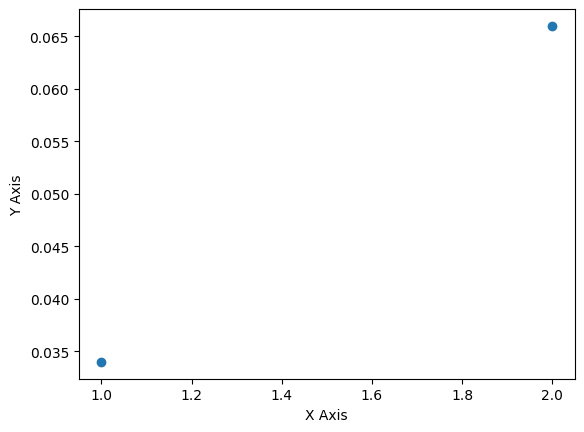

In [18]:
t2_nptr_init_tr, t2_cum_init_tr = t2_risk_calc(45, 'male', 0.002, 0.002, 0, 'yes')
x_values = [1, 2]
y_values = [t2_nptr_init_tr, t2_cum_init_tr]

plt.scatter(x_values, y_values)
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.show()

In [19]:
#INPUTS BELOW

In [20]:
#Inputs for following graphics/function applications:
sex = 'male'
age = 45
init_tr_1 = 0.00261
sub_tr_1 = 0.00261
t1_name = 'Observation'
init_tr_2 = 0.05
sub_tr_2 = 0.0
t2_name = 'Microsurgery'
standard = 'yes'

In [21]:
#Optional PHASES for aneurysm:
#size in mm
size_of_aneurysm = 7
#     site of aneurysm: 1 == ICA, 2 == MCA, 3 == ACA/Pcom/posterior
site_aneurysm = 2
#     prior SAH : Yes == 1, no == 0
prior_sah = 0
#     population: North American/European == 1, Japanese == 2, Finnish == 3
population = 1
#     hypertension: Yes == 1, no == 0
hypertension = 0
annual_rupture_risk = phases_score(age, size_of_aneurysm, site_aneurysm, prior_sah, population, hypertension)
print(f'5-year-rupture risk is {(1-(1-annual_rupture_risk)**5)*100:.2f}% and annual rupture risk is {(annual_rupture_risk*100):.3f}%')
init_tr_1 = annual_rupture_risk
sub_tr_1 = annual_rupture_risk

5-year-rupture risk is 1.30% and annual rupture risk is 0.261%


In [22]:
#simple nptr and cumulative risk for single procedure with specific age/gender
nptr_risk_calc1 = nptr_risk_calc(age, sex, init_tr_1, sub_tr_1, standard)
nptr_risk_calc2 = nptr_risk_calc(age, sex, init_tr_2, sub_tr_2, standard)
print(nptr_risk_calc1, nptr_risk_calc2)

(np.float64(1.520071108473951), np.float64(0.08537518287366108)) (np.float64(1.7049999999999998), np.float64(0.050000000000000044))


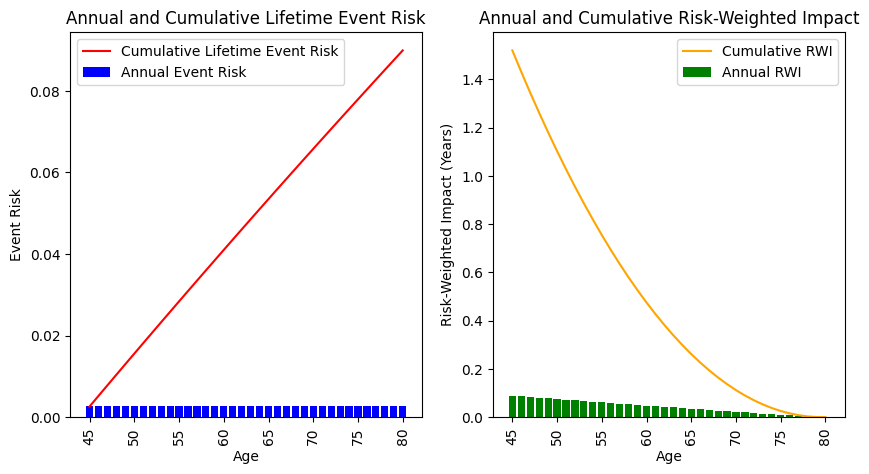

In [23]:
#graphs of calculations of each metric for specific age/sex/procedure (i.e. Figure 1AB)
individual_graphs(age, sex, init_tr_1, sub_tr_1, standard)

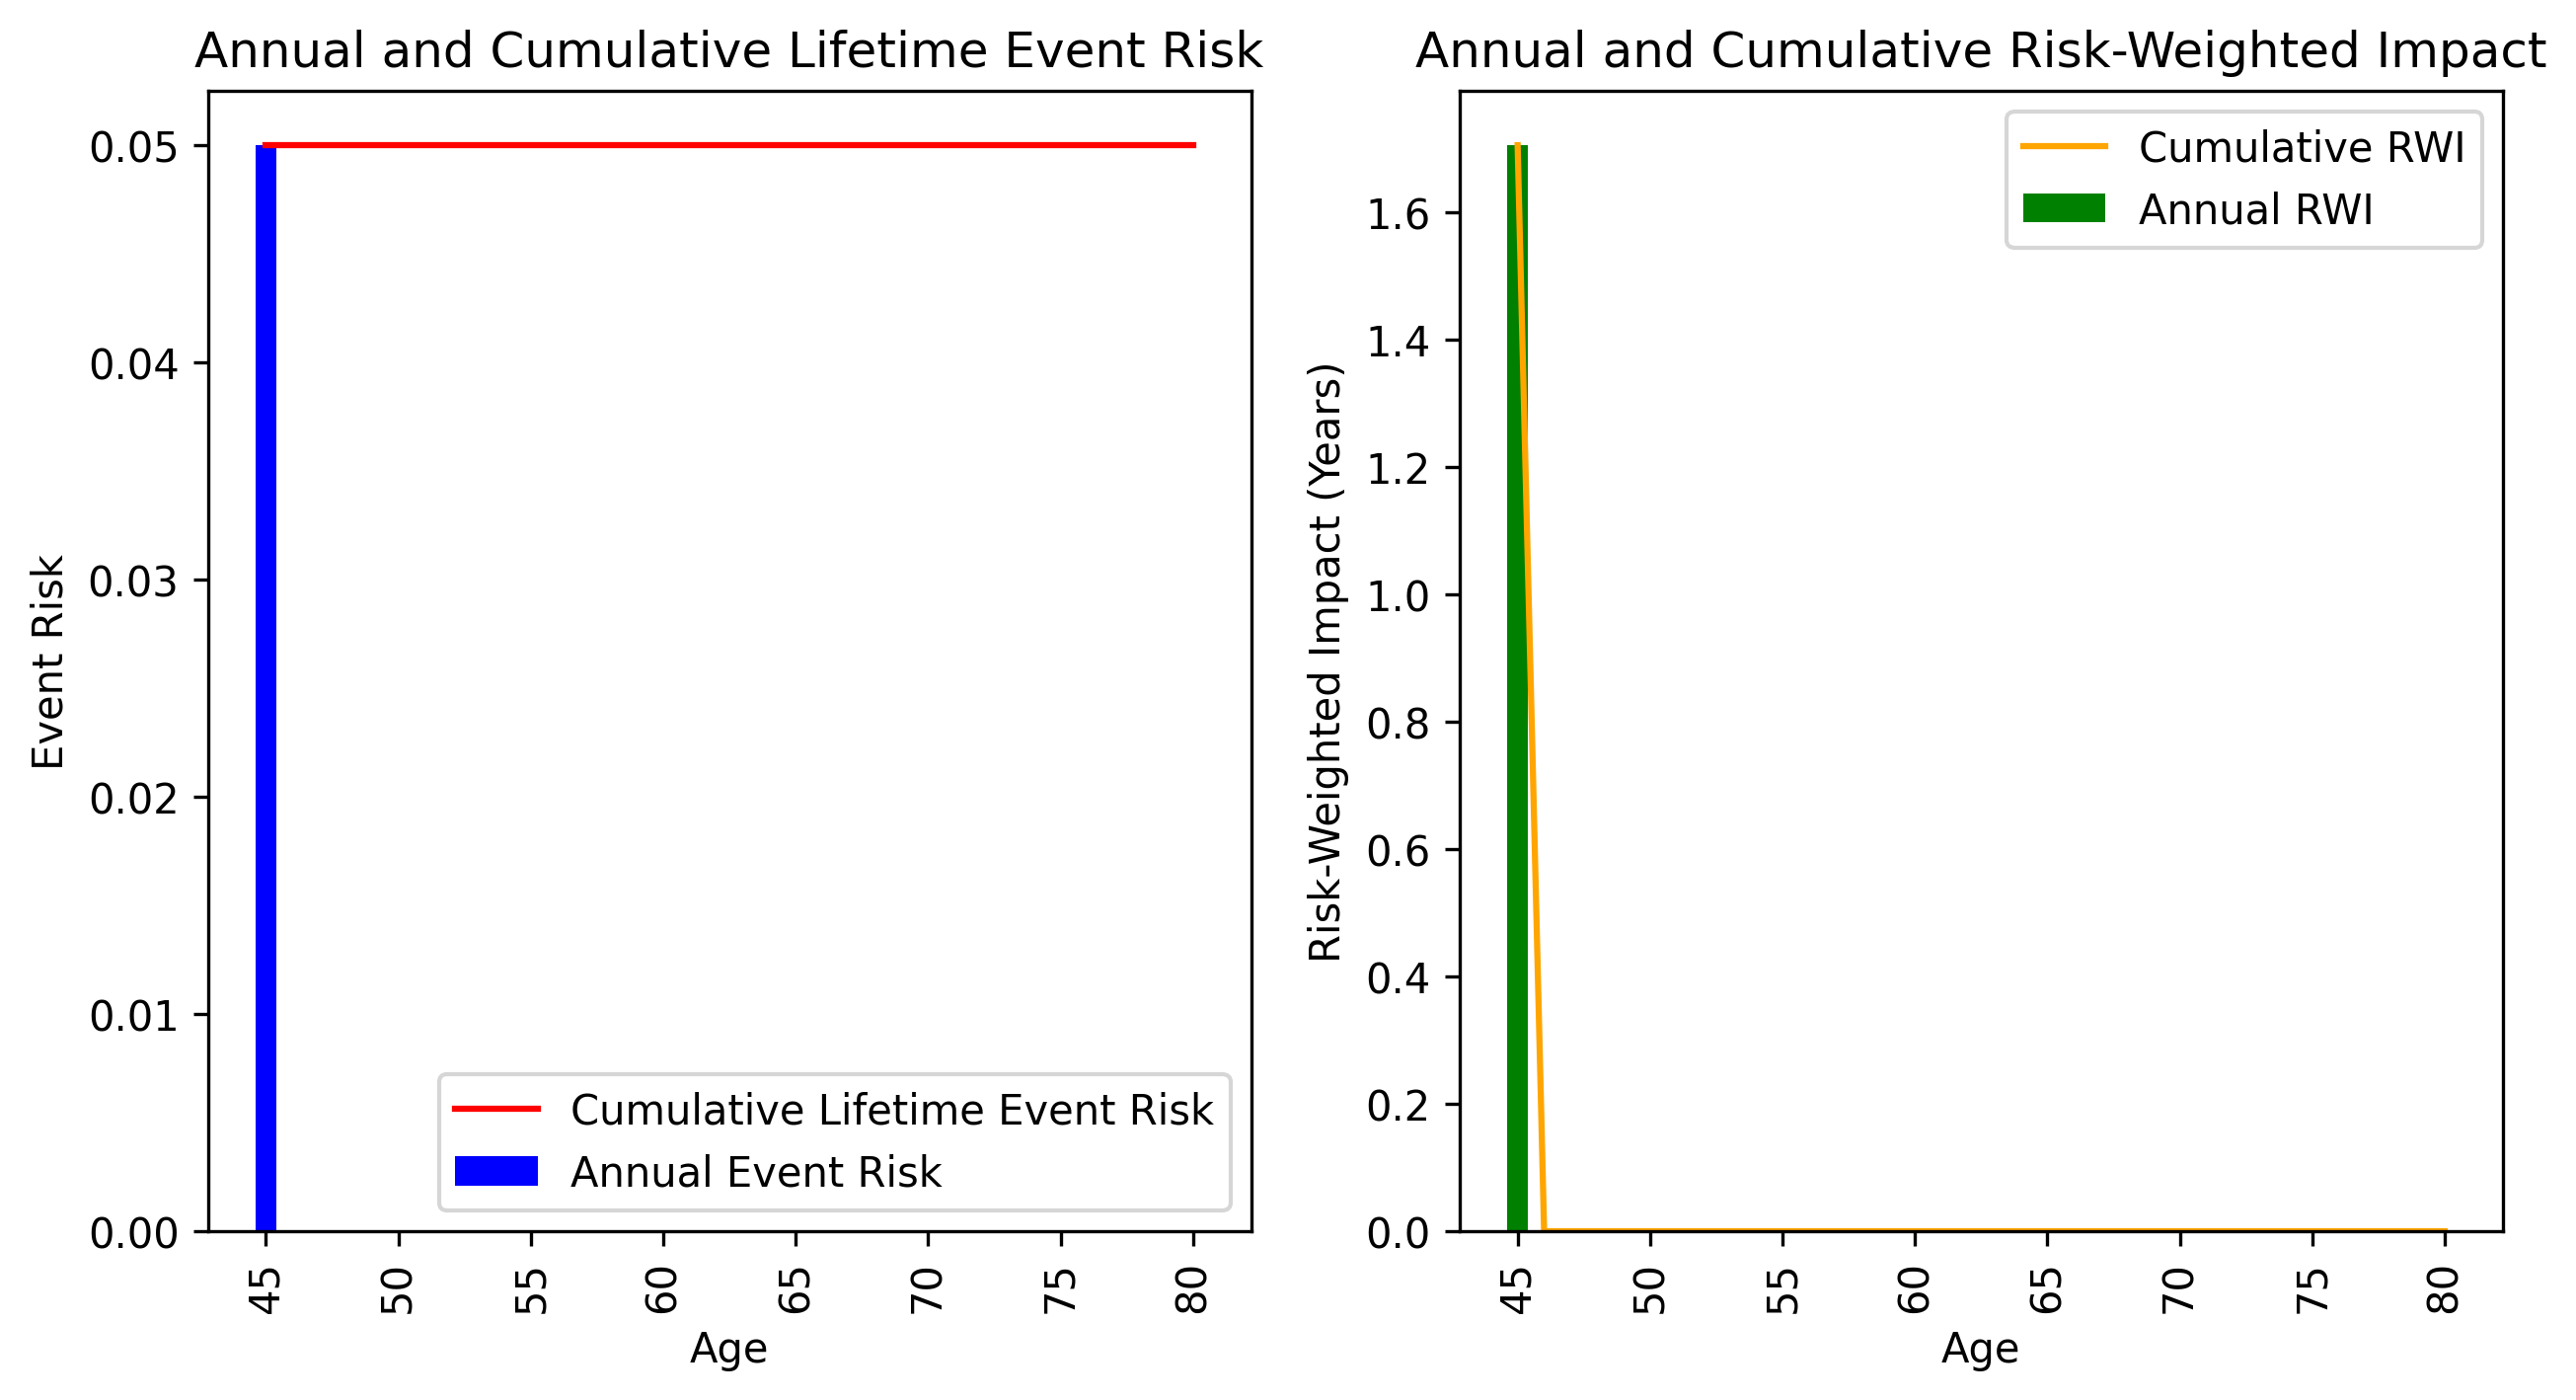

In [24]:
#graphs of calculations of each metric for second specific age/sex/procedure (i.e. Figure 1CD)
individual_graphs(age, sex, init_tr_2, sub_tr_2, standard)

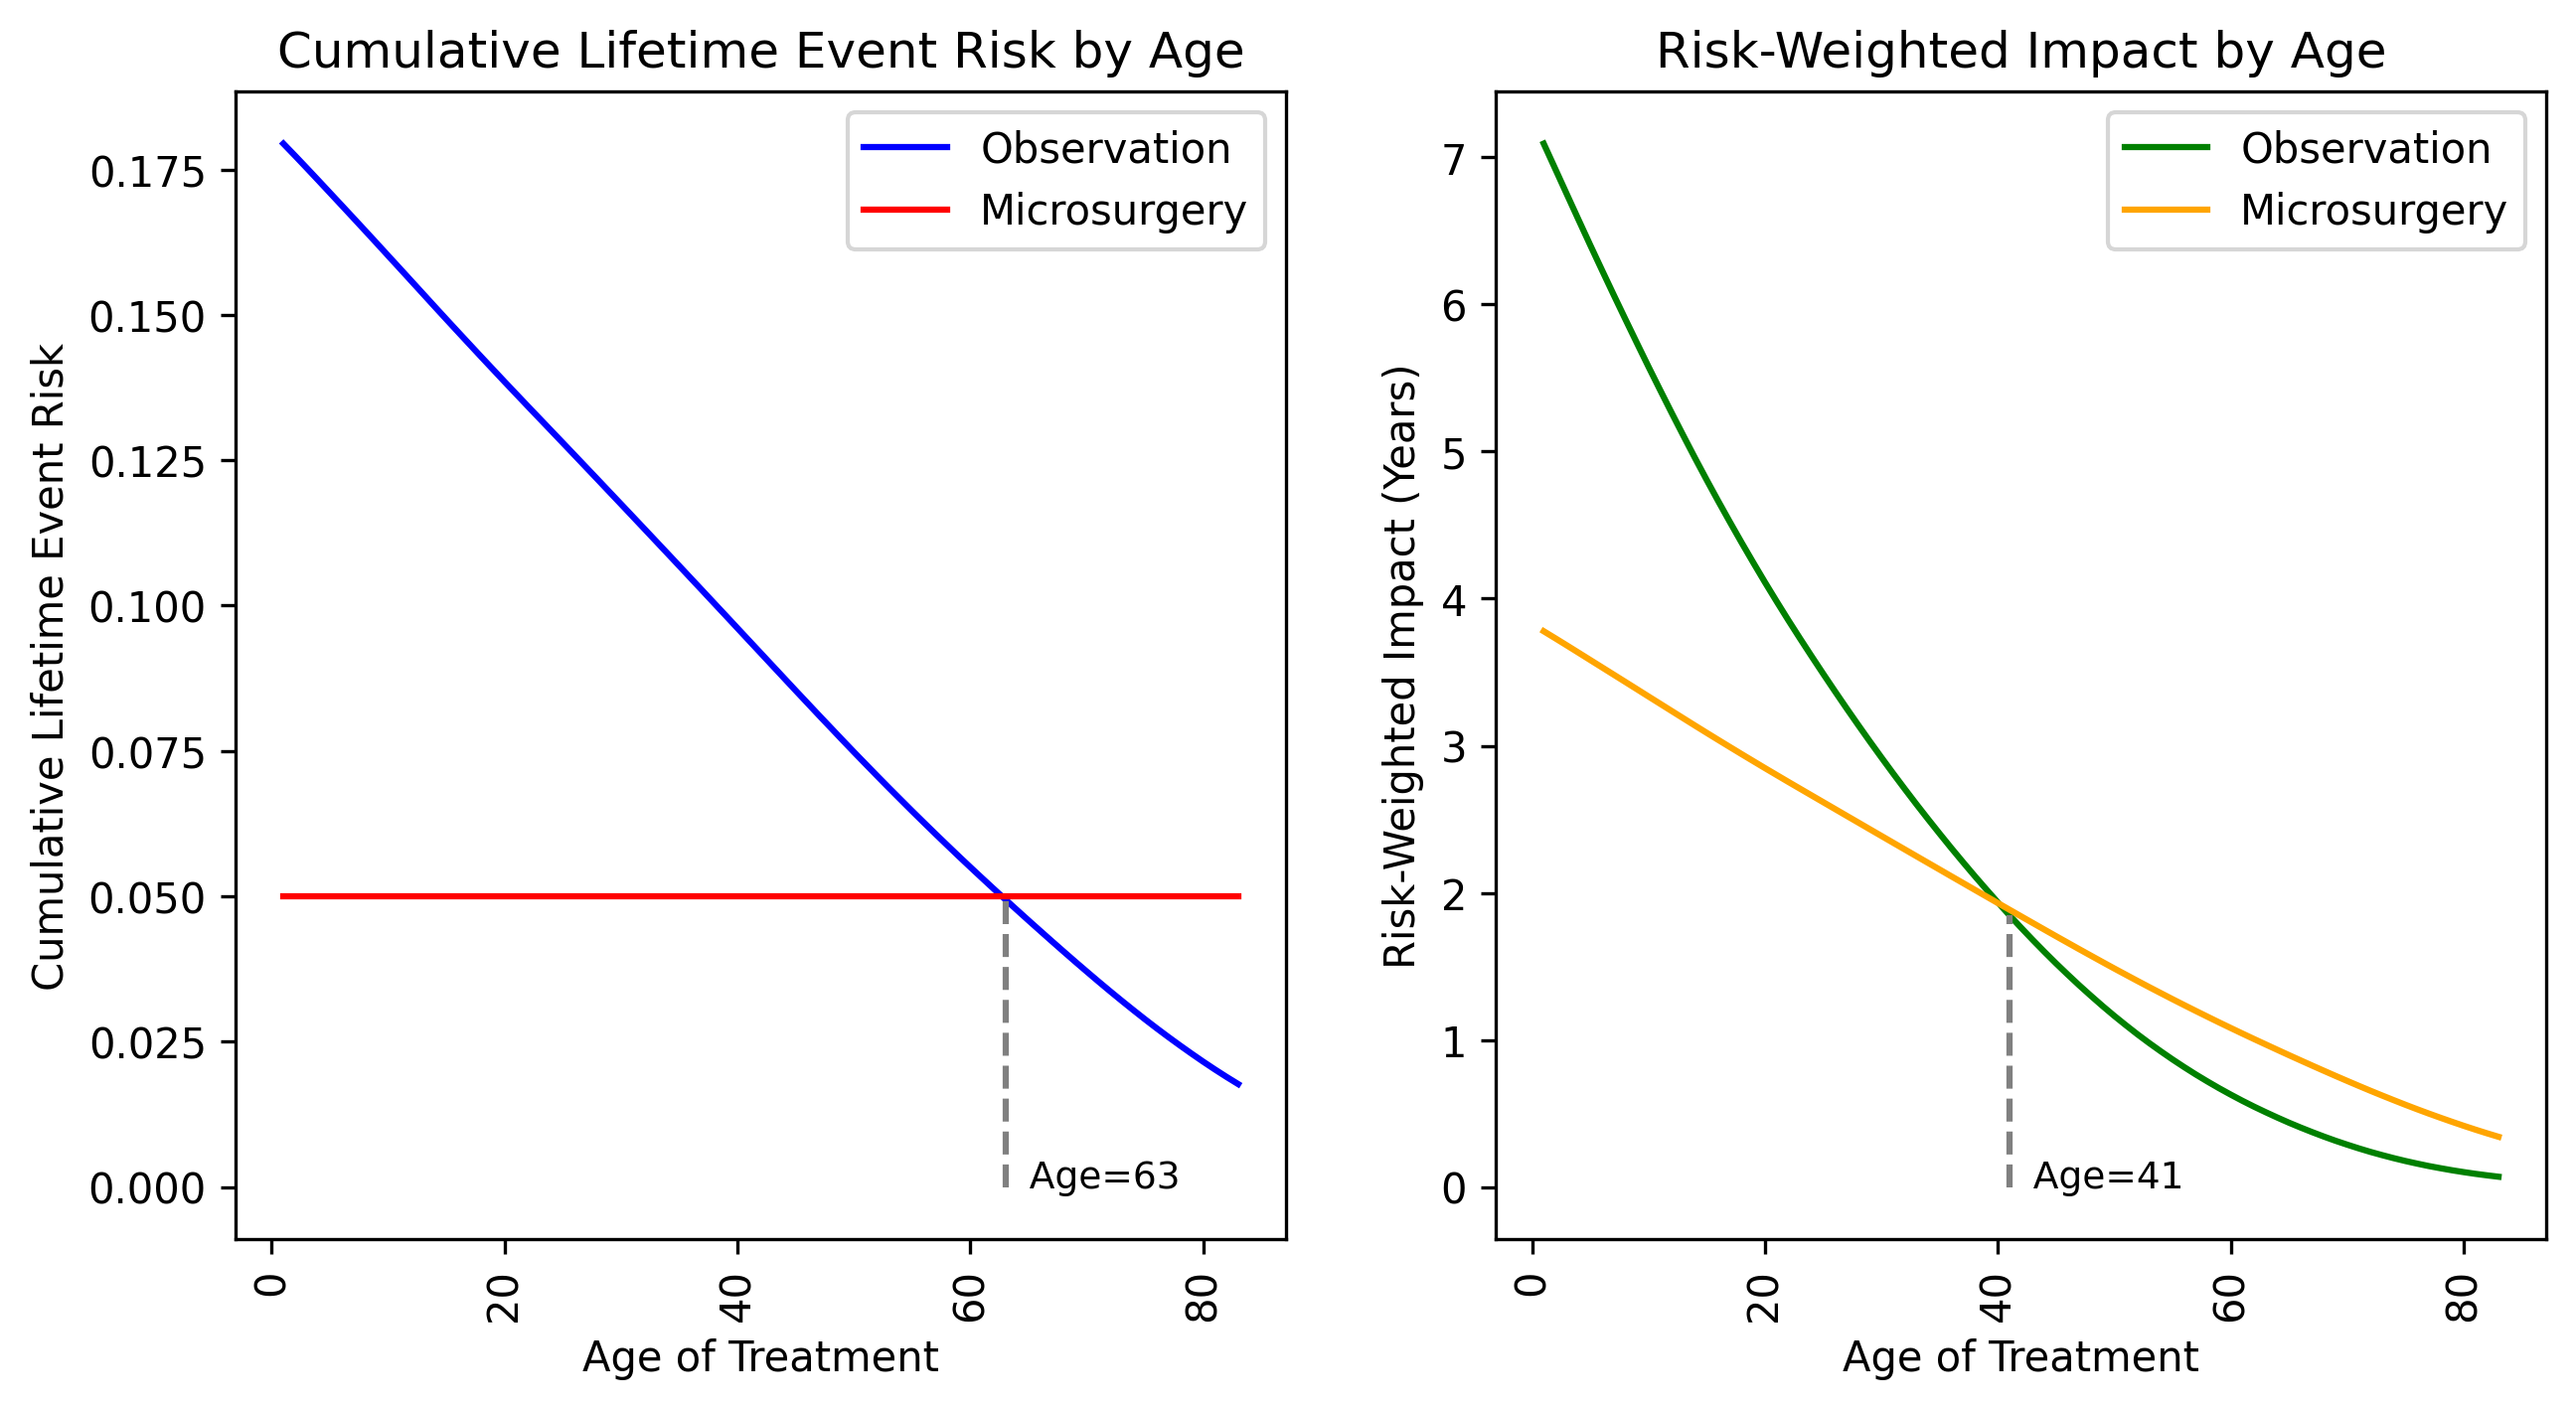

In [25]:
#Comparison of 2 treatments across all ages with sex/risks, with ages of intersection (i.e. Figure 2)
treatment_compare(sex, init_tr_1, sub_tr_1, init_tr_2, sub_tr_2, t1_name=t1_name, t2_name=t2_name, standard=standard)

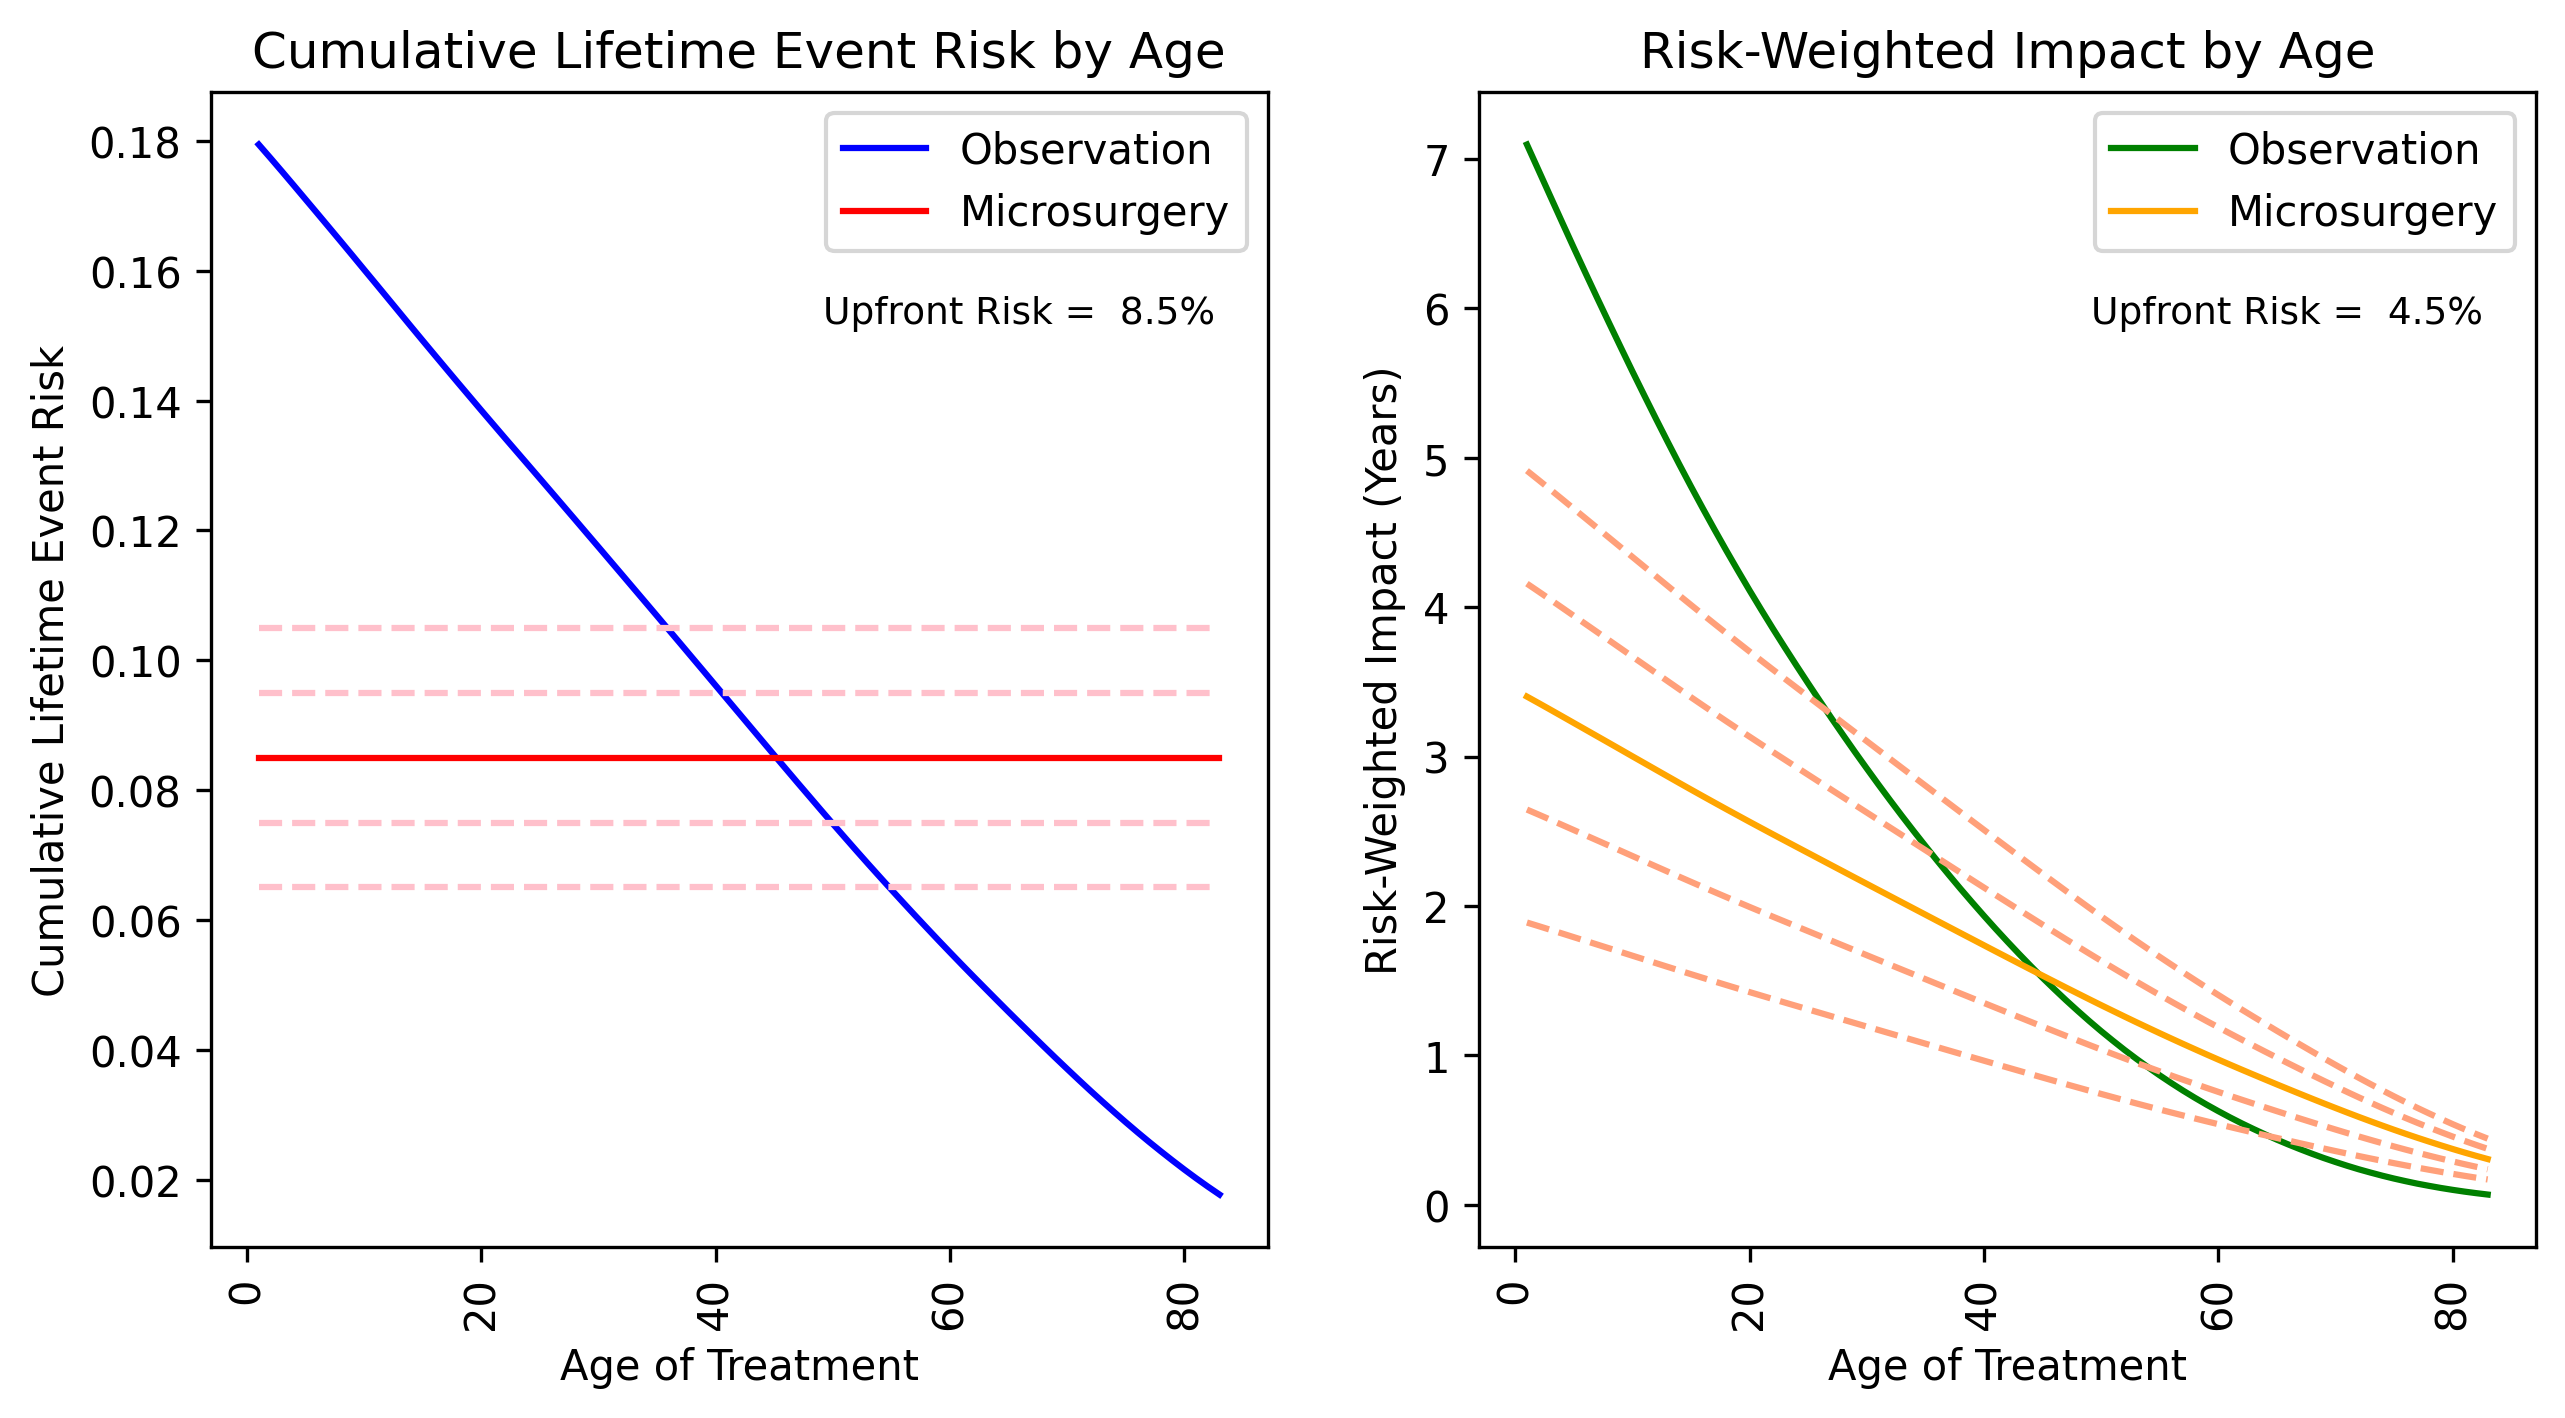

In [26]:
#Comparison of 2 treatments with second initial treatment modulated to have intersection at stated age (i.e. Figure 3)
treatment_risk_compare(age, sex, init_tr_1, sub_tr_1, sub_tr_2, t1_name=t1_name, t2_name=t2_name, standard=standard)

In [27]:
#Minimal inputs
phases_min_risks_male_event, phases_min_risks_male_nptr = minimum_eq_risks_all_ages('male', t2_sub_tr=0, standard='no')
phases_min_risks_female_event, phases_min_risks_female_nptr = minimum_eq_risks_all_ages('female', t2_sub_tr=0, standard='no')

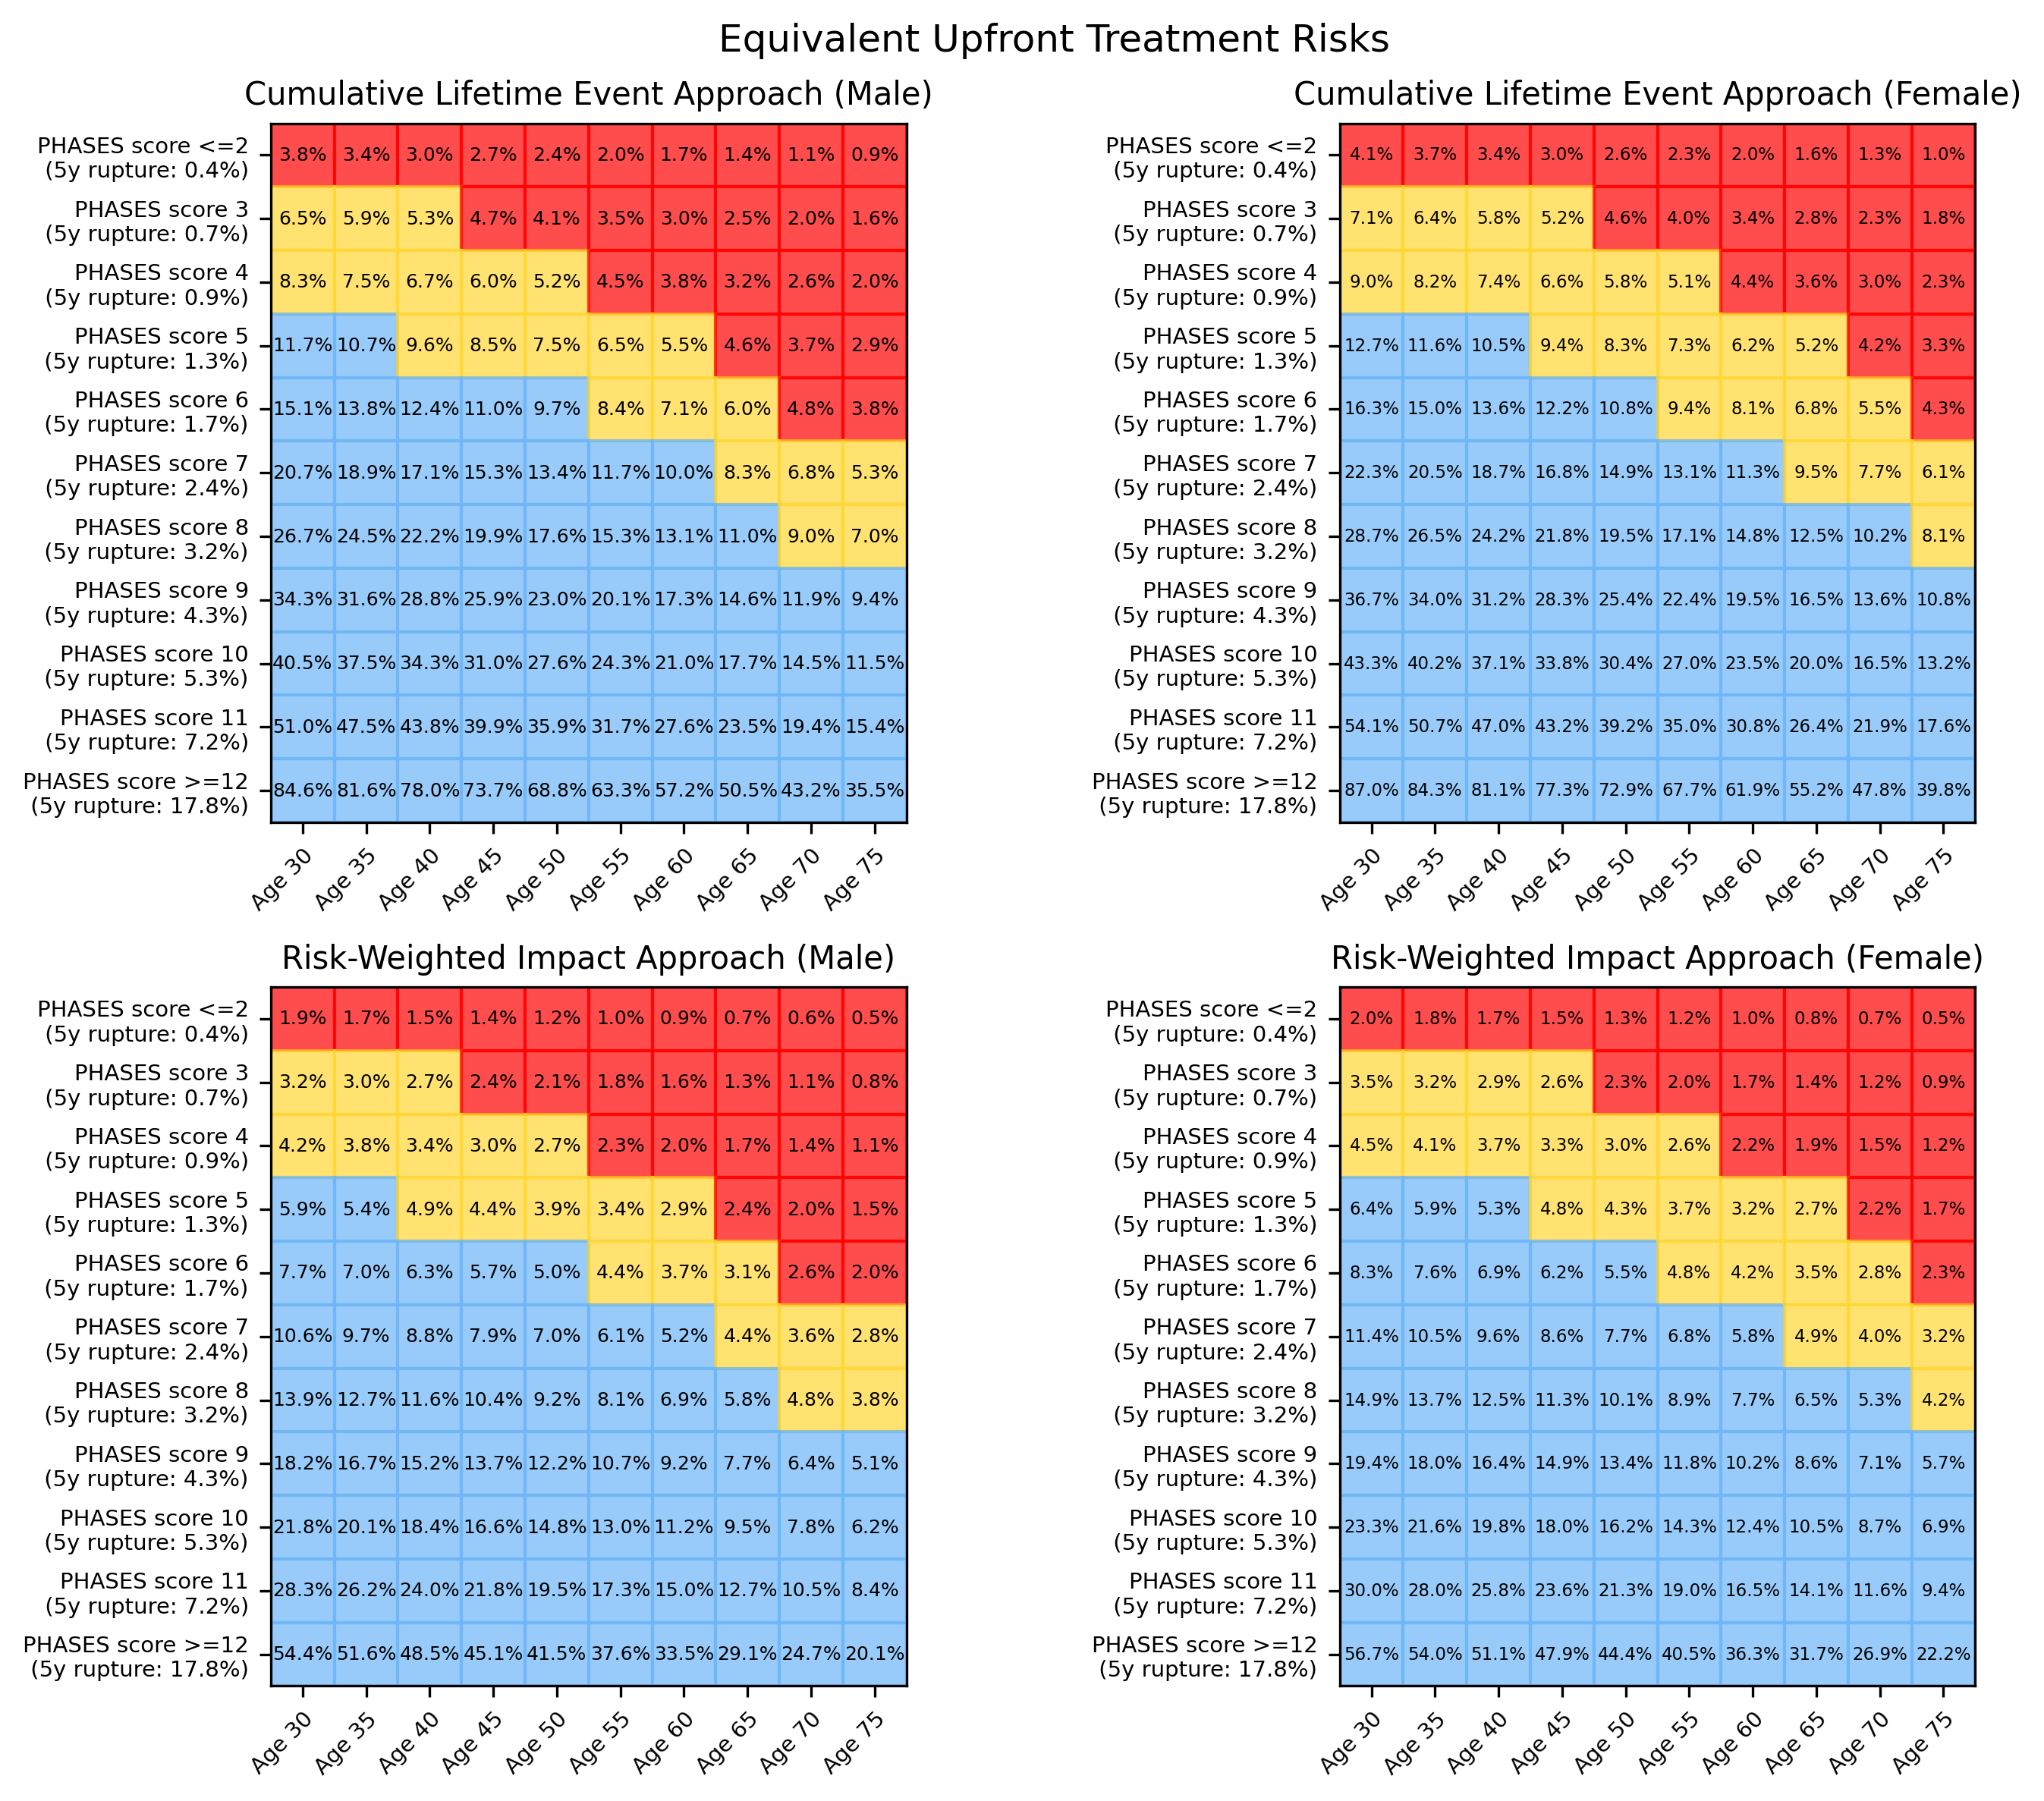

In [28]:
#Threshold for coloring, Figure 4
threshold = 0.05
figure4(threshold, phases_min_risks_male_event, phases_min_risks_male_nptr, phases_min_risks_female_event, phases_min_risks_female_nptr)

In [29]:
ratio_male = tables_max_risk(phases_min_risks_male_event, 0, 85, 1)/tables_max_risk(phases_min_risks_male_nptr, 0, 85, 1)
ratio_female = tables_max_risk(phases_min_risks_female_event, 0, 85, 1)/tables_max_risk(phases_min_risks_female_nptr, 0, 85, 1)

def summary_stats(df):
  summary_dict = {
    'median': np.median(df.values),
    'q1': np.percentile(df.values, 25),
    'q3': np.percentile(df.values, 75),
    'min': np.min(df.values),
    'max': np.max(df.values),
    'mean': np.mean(df.values),
    'std_m': np.std(ratio_male.values)
  }
  return summary_dict

summary_stat_male = summary_stats(ratio_male)
summary_stat_female = summary_stats(ratio_female)
print(summary_stat_male, summary_stat_female)

{'median': np.float64(1.896551724137931), 'q1': np.float64(1.8389976958525347), 'q3': np.float64(1.9611020047913252), 'min': np.float64(1.4080118694362016), 'max': np.float64(2.076923076923077), 'mean': np.float64(1.8787846916537243), 'std_m': np.float64(0.11743025766225407)} {'median': np.float64(1.9248120300751879), 'q1': np.float64(1.8607721580047523), 'q3': np.float64(1.980487340567295), 'min': np.float64(1.3944687045123725), 'max': np.float64(2.1666666666666665), 'mean': np.float64(1.8971126098895457), 'std_m': np.float64(0.11743025766225407)}


In [30]:
#Minimal inputs - STANDARD
phases_min_risks_male_event_standard, phases_min_risks_male_nptr_standard = minimum_eq_risks_all_ages('male', t2_sub_tr=0, standard='yes')
phases_min_risks_female_event_standard, phases_min_risks_female_nptr_standard = minimum_eq_risks_all_ages('female', t2_sub_tr=0, standard='yes')

In [31]:
ratio_male_standard = tables_max_risk(phases_min_risks_male_event_standard, 0, 85, 1)/tables_max_risk(phases_min_risks_male_nptr_standard, 0, 85, 1)
ratio_female_standard = tables_max_risk(phases_min_risks_female_event_standard, 0, 85, 1)/tables_max_risk(phases_min_risks_female_nptr_standard, 0, 85, 1)
summary_stat_male_standard = summary_stats(ratio_male_standard)
summary_stat_female_standard = summary_stats(ratio_female_standard)
print(summary_stat_male_standard, summary_stat_female_standard)

{'median': np.float64(1.8571428571428572), 'q1': np.float64(1.791582329317269), 'q3': np.float64(1.909090909090909), 'min': np.float64(1.3793604651162792), 'max': np.float64(2.0), 'mean': np.float64(1.8328187966095812), 'std_m': np.float64(0.11743025766225407)} {'median': np.float64(1.8579881656804733), 'q1': np.float64(1.7971497727721795), 'q3': np.float64(1.9090909090909094), 'min': np.float64(1.3607954545454546), 'max': np.float64(2.0), 'mean': np.float64(1.8332974103761965), 'std_m': np.float64(0.11743025766225407)}


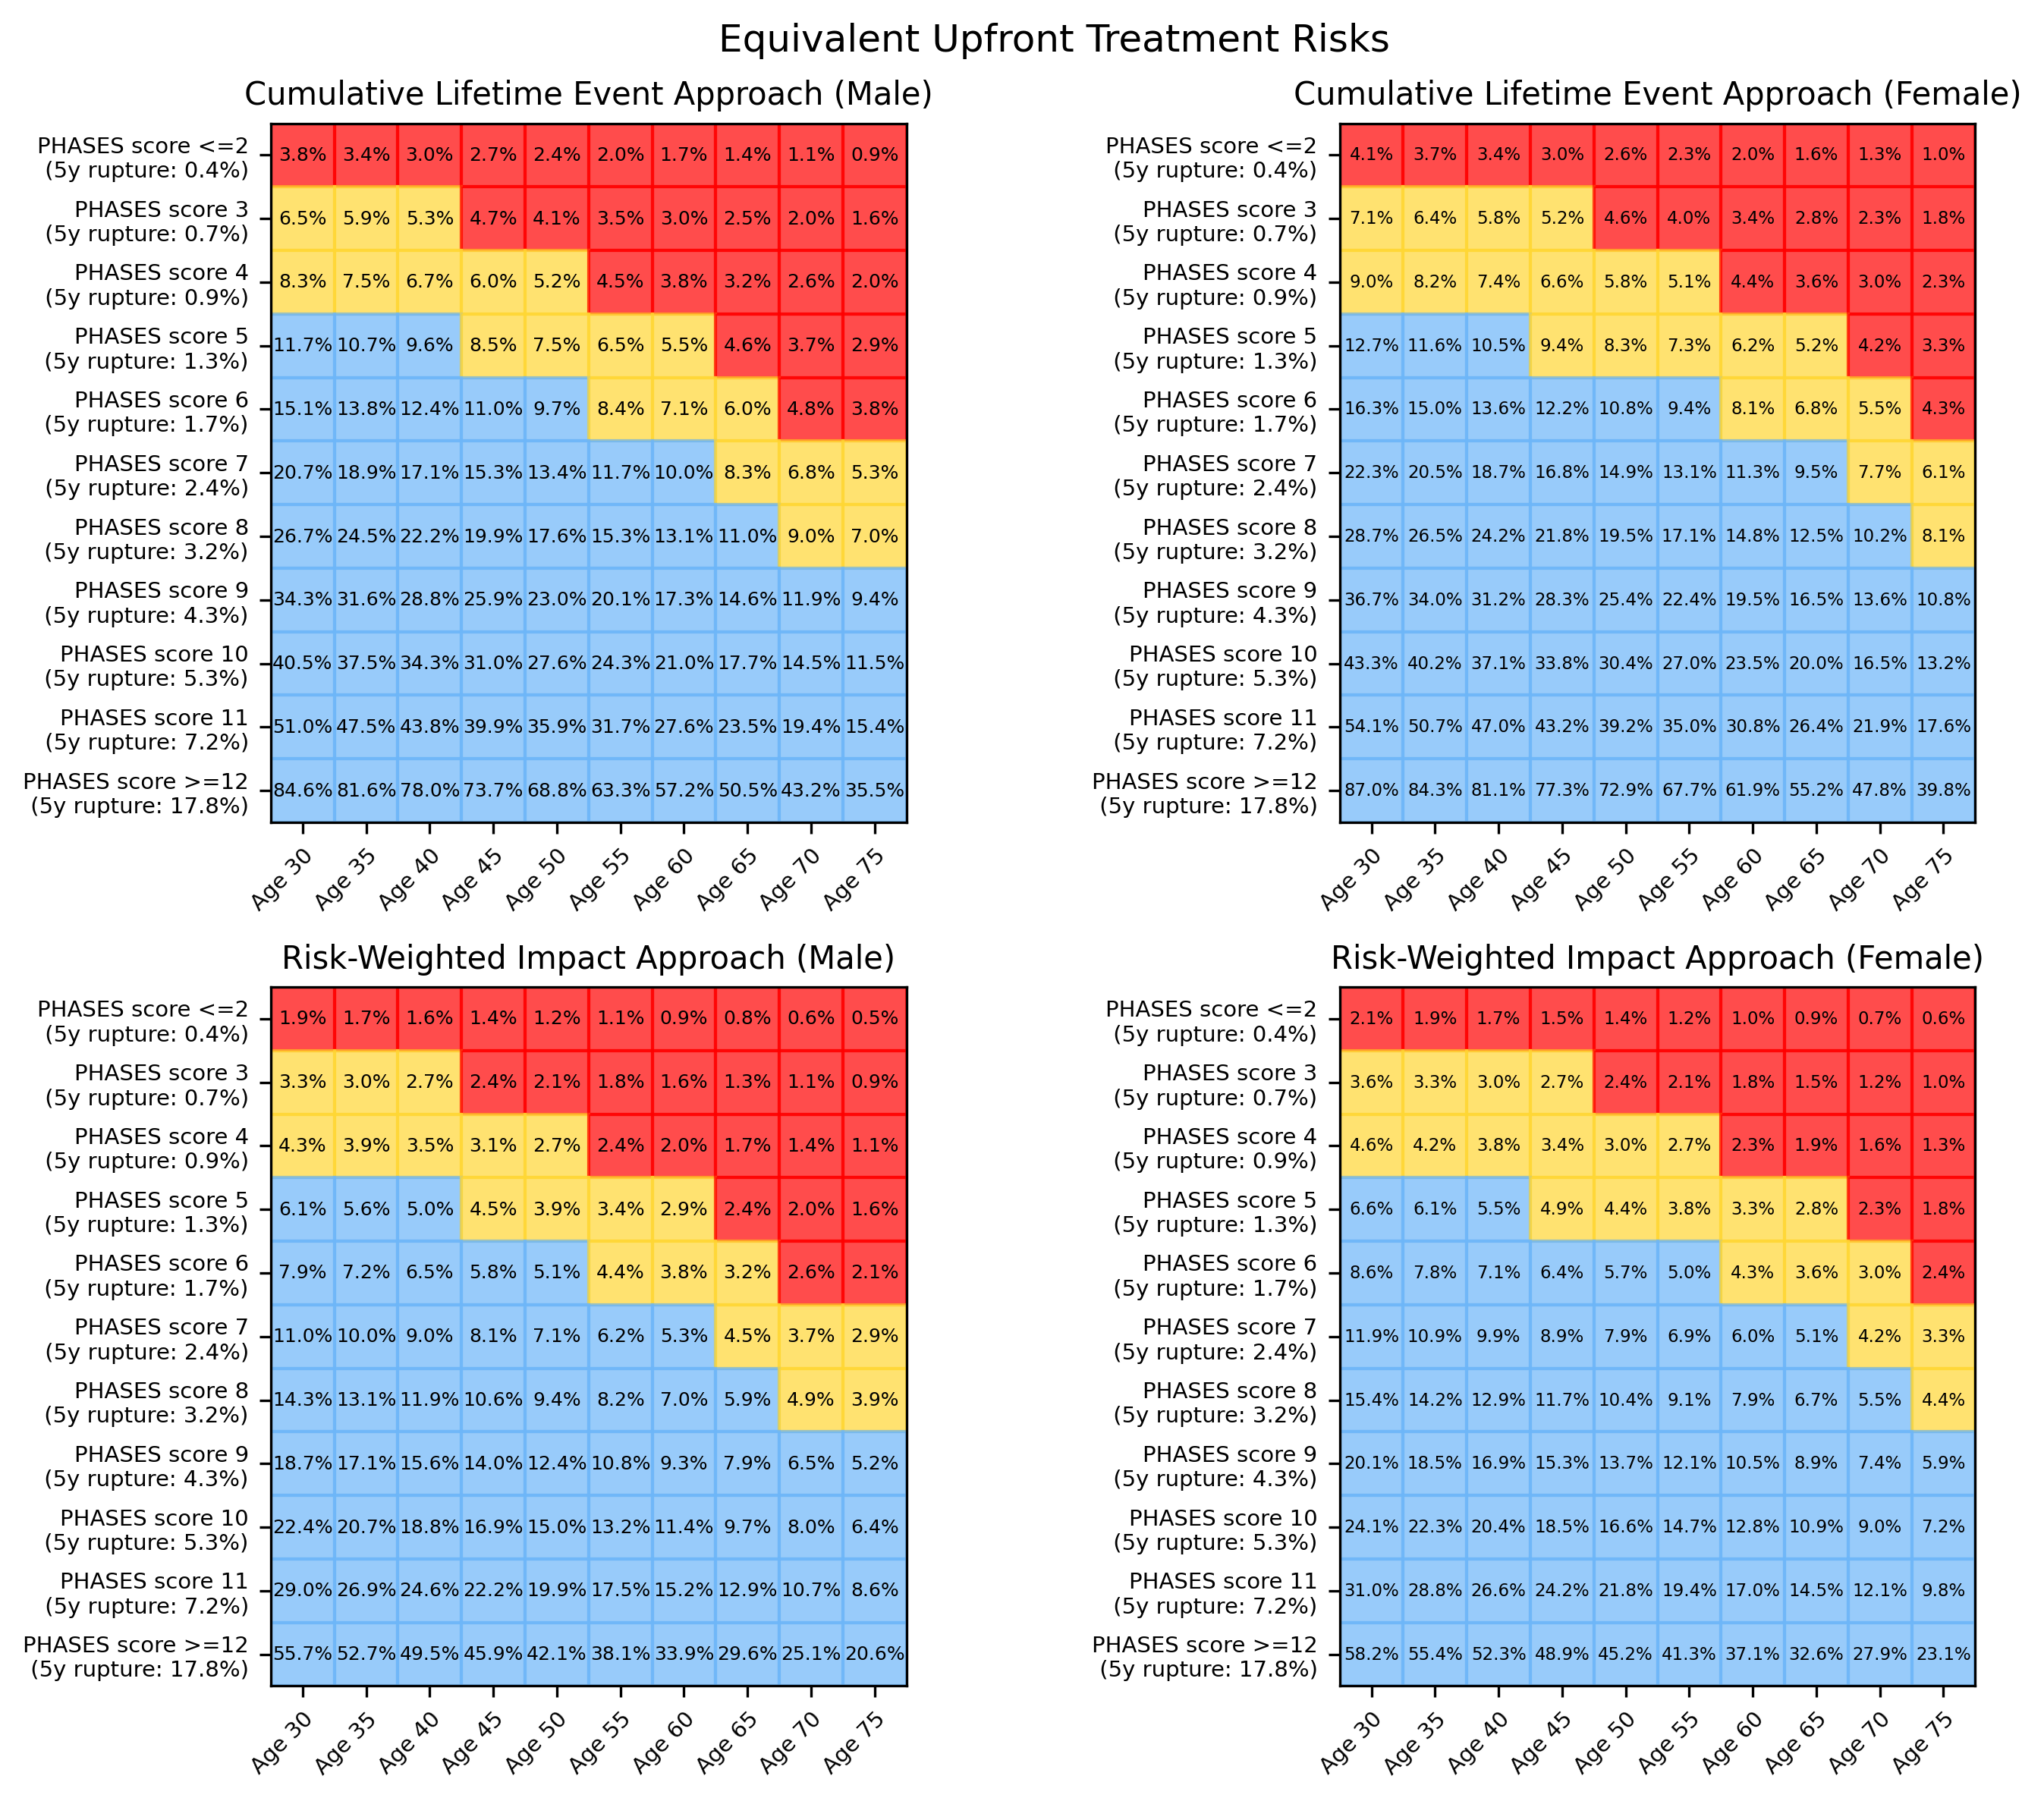

In [32]:
threshold = 0.05
figure4(threshold, phases_min_risks_male_event_standard, phases_min_risks_male_nptr_standard, phases_min_risks_female_event_standard, phases_min_risks_female_nptr_standard)